In [1]:
# Assignment Module 5
# --- Q3. Computer Vision Problem Formulation and CNN Prototype — Graded Assessment ---

In [2]:
!mkdir ../data
# Now upload the datasets provided

Loading images from: normal
Loading images from: scratch
Loading images from: dent
Loading images from: stain

Dataset Loaded Successfully
Total Images: 480
Image Shape: (128, 128, 3)

Class Distribution:
normal: 120
scratch: 120
dent: 120
stain: 120


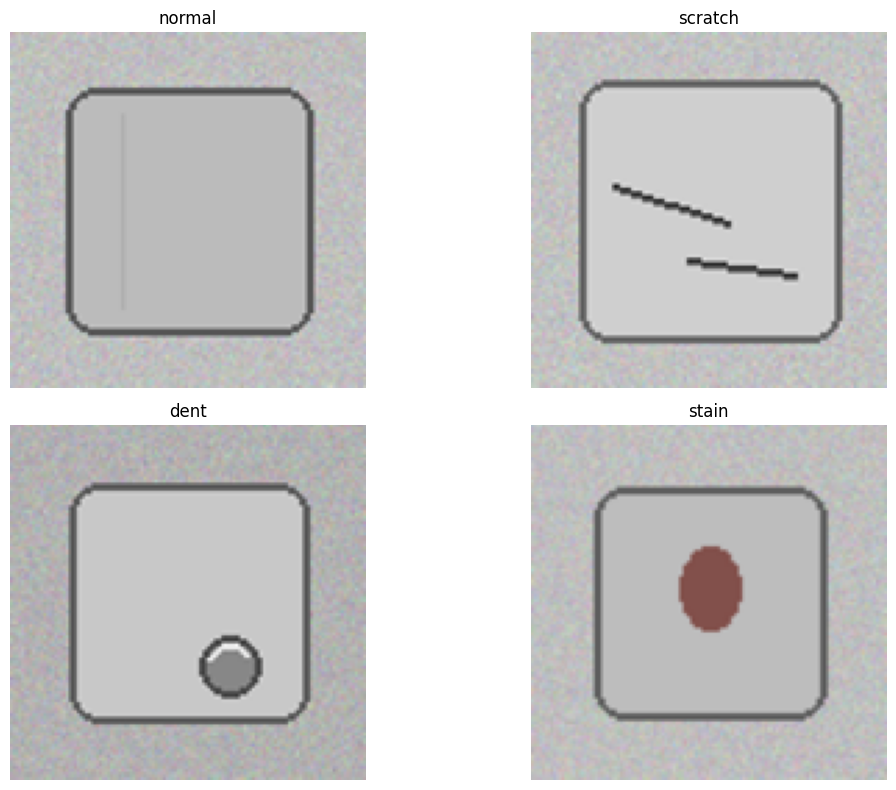

In [10]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# ============================================================
# 2. DATASET PATH
# ============================================================

# CHANGE THIS PATH TO YOUR DATASET LOCATION
dataset_path = "../data/images"

# ============================================================
# 3. LOAD DATASET
# ============================================================

classes = ['normal', 'scratch', 'dent', 'stain']

images = []
labels = []

IMG_SIZE = 128

for label, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, class_name)
    print(f"Loading images from: {class_name}")
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path).convert('RGB')
            # Resize image
            img = img.resize((IMG_SIZE, IMG_SIZE))
            # Convert to numpy array
            img_array = np.array(img)
            images.append(img_array)
            labels.append(label)
        except Exception as e:
            print(f"Error loading image {img_name}: {e}")

# Convert lists to arrays
X = np.array(images)
y = np.array(labels)

print("\nDataset Loaded Successfully")
print("Total Images:", len(X))
print("Image Shape:", X[0].shape)

# ============================================================
# 4. DATASET EXPLORATION
# ============================================================

print("\nClass Distribution:")

for i, class_name in enumerate(classes):
    count = np.sum(y == i)
    print(f"{class_name}: {count}")

# ============================================================
# 5. DISPLAY SAMPLE IMAGES
# ============================================================

plt.figure(figsize=(12, 8))
for i, class_name in enumerate(classes):
    idx = np.where(y == i)[0][0]
    plt.subplot(2, 2, i + 1)
    plt.imshow(X[idx])
    plt.title(class_name)
    plt.axis("off")
plt.tight_layout()
plt.show()

# ============================================================
# 6. NORMALIZE IMAGES
# ============================================================

X = X.astype('float32') / 255.0

# ============================================================
# 7. ONE-HOT ENCODE LABELS
# ============================================================

y = to_categorical(y, num_classes=len(classes))

In [11]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ============================================================
# 8. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

# ============================================================
# 9. DATA AUGMENTATION
# ============================================================

datagen = ImageDataGenerator(rotation_range=20, zoom_range=0.2, horizontal_flip=True)
datagen.fit(X_train)


Training Samples: 384
Testing Samples: 96


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout)

# ============================================================
# 10. BUILD CNN MODEL
# ============================================================

model = Sequential([

    # Convolution Layer 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Pooling Layer 1
    MaxPooling2D(pool_size=(2, 2)),

    # Convolution Layer 2
    Conv2D(64, (3, 3), activation='relu'),

    # Pooling Layer 2
    MaxPooling2D(pool_size=(2, 2)),

    # Convolution Layer 3
    Conv2D(128, (3, 3), activation='relu'),

    # Pooling Layer 3
    MaxPooling2D(pool_size=(2, 2)),

    # Flatten Layer
    Flatten(),

    # Dense Layer
    Dense(128, activation='relu'),

    # Dropout Layer
    Dropout(0.5),

    # Output Layer
    Dense(len(classes), activation='softmax')
])

# ============================================================
# 11. COMPILE MODEL
# ============================================================

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# ============================================================
# 12. MODEL SUMMARY
# ============================================================

print("\nCNN MODEL SUMMARY")
model.summary()


CNN MODEL SUMMARY


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.2370 - loss: 1.5269 - val_accuracy: 0.2500 - val_loss: 1.3824
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.3177 - loss: 1.3782 - val_accuracy: 0.4271 - val_loss: 1.3810
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.3620 - loss: 1.3459 - val_accuracy: 0.4896 - val_loss: 1.2602
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.4896 - loss: 1.1268 - val_accuracy: 0.6354 - val_loss: 0.9639
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.3854 - loss: 1.2448 - val_accuracy: 0.2917 - val_loss: 1.3052
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.3359 - loss: 1.2444 - val_accuracy: 0.5000 - val_loss: 1.0653
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.5339 - loss: 0.9376 - val_accuracy: 0.5938 - val_loss: 0.8185
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.5573 - loss: 0.8506 - val_accuracy: 0.7292 - val_loss:

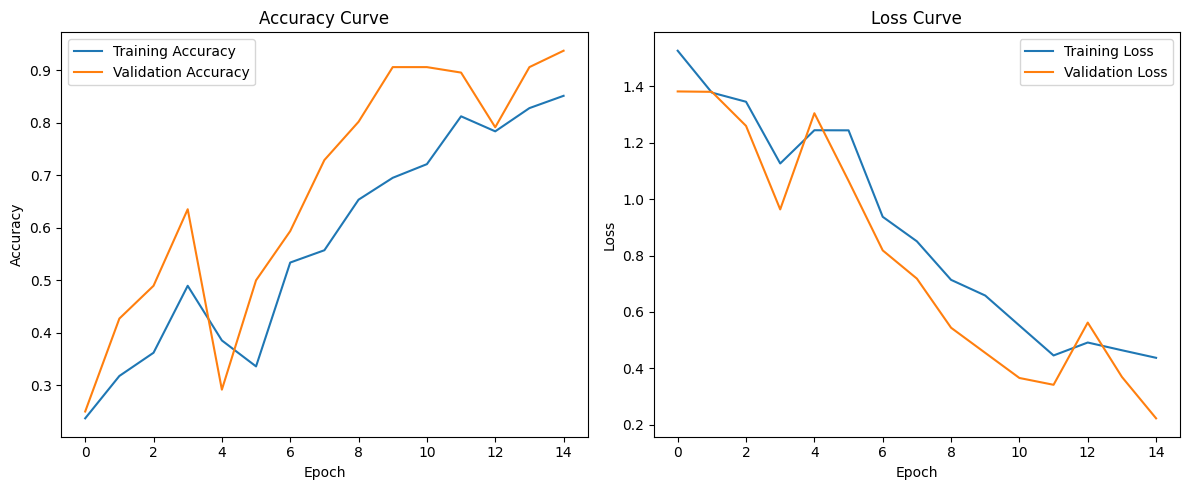

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step


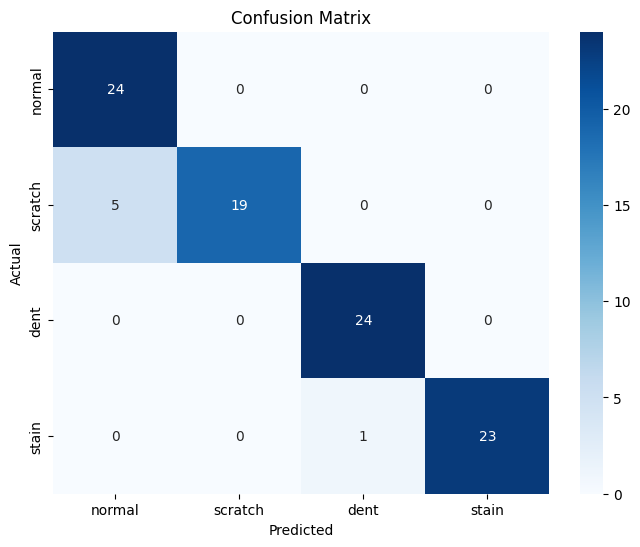


Classification Report:

              precision    recall  f1-score   support

      normal       0.83      1.00      0.91        24
     scratch       1.00      0.79      0.88        24
        dent       0.96      1.00      0.98        24
       stain       1.00      0.96      0.98        24

    accuracy                           0.94        96
   macro avg       0.95      0.94      0.94        96
weighted avg       0.95      0.94      0.94        96



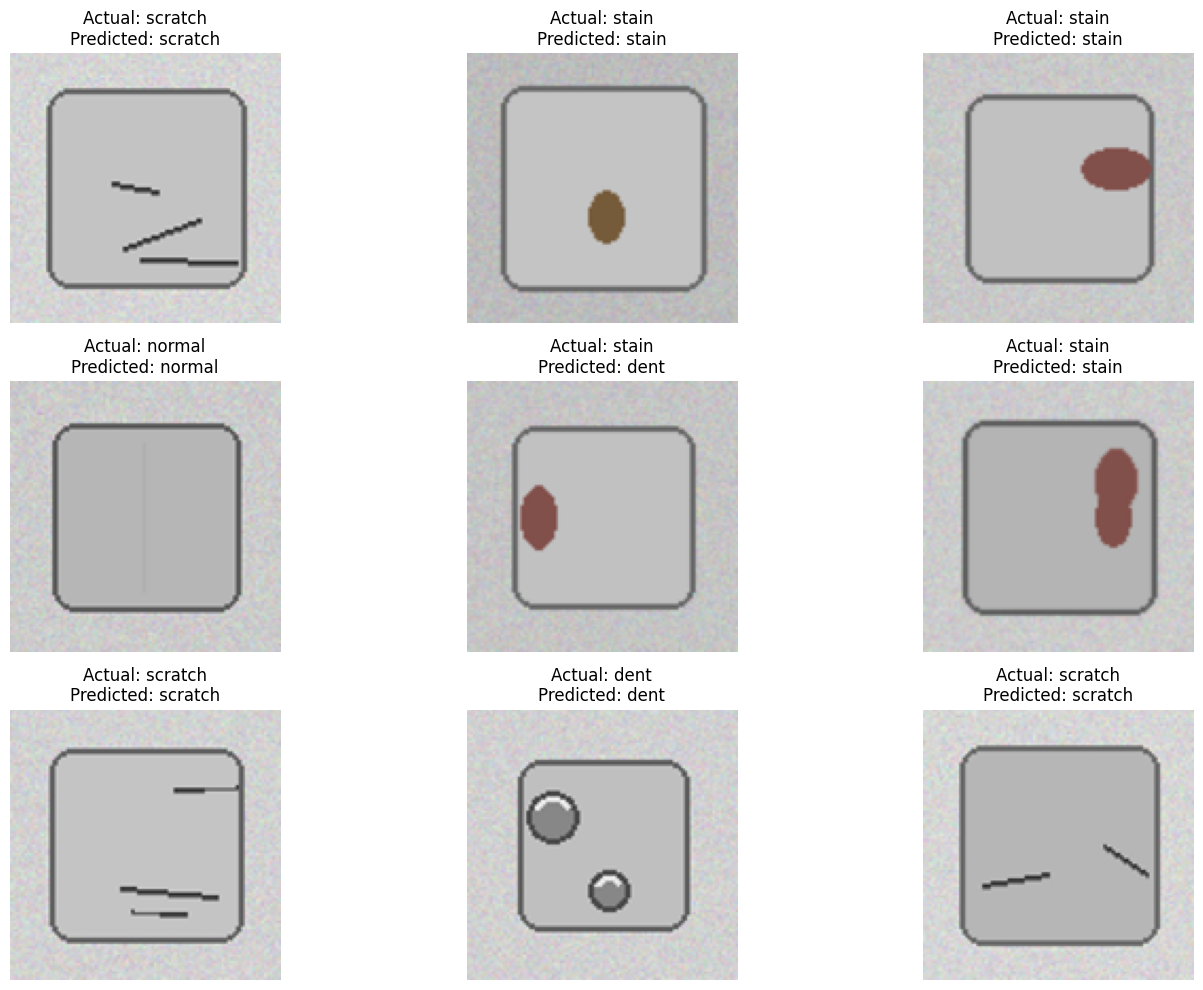

In [13]:
# ============================================================
# 13. TRAIN MODEL
# ============================================================

history = model.fit(datagen.flow(X_train, y_train, batch_size=32), epochs=15, validation_data=(X_test, y_test))

# ============================================================
# 14. EVALUATE MODEL
# ============================================================

test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# ============================================================
# 15. PLOT ACCURACY CURVES
# ============================================================

plt.figure(figsize=(12, 5))
# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('accuracy_loss_curves.png') # Expected in repository
plt.tight_layout()
plt.show()

# ============================================================
# 16. CONFUSION MATRIX
# ============================================================

# Predict classes
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig('confusion_matrix.png')
plt.show()

# ============================================================
# 17. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=classes))

# ============================================================
# 18. SAMPLE PREDICTIONS
# ============================================================

plt.figure(figsize=(15, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    random_idx = np.random.randint(0, len(X_test))
    img = X_test[random_idx]
    actual_label = classes[np.argmax(y_test[random_idx])]
    prediction = model.predict(np.expand_dims(img, axis=0), verbose=0)
    predicted_label = classes[np.argmax(prediction)]
    plt.imshow(img)
    plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label}")
    plt.axis("off")
plt.savefig('prediction_outputs.png')
plt.tight_layout()
plt.show()

# ============================================================
# END OF PROJECT
# ============================================================